In [20]:
!pip install transformers torchvision pillow grad-cam lime gradio -q

In [21]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from transformers import DistilBertTokenizer, DistilBertModel
from PIL import Image
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [22]:
class ImageEmbedder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.embedding_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU()
        )
    def forward(self, x):
        return self.embedding_head(self.backbone(x))

class TextEmbedder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        self.embedding_head = nn.Sequential(
            nn.Linear(768, 768),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    def forward(self, input_ids, attention_mask):
        cls = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]
        return self.embedding_head(cls)

class FusionScorer(nn.Module):
    def __init__(self):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, img_emb, text_emb):
        return self.fusion(torch.cat([img_emb, text_emb], dim=1))

print('Classes defined')

Classes defined


In [23]:
from google.colab import files
files.upload()

image_embedder = ImageEmbedder().to(device)
text_embedder = TextEmbedder().to(device)
fusion_model = FusionScorer().to(device)

checkpoint = torch.load('multimodal_ad_scorer.pt', map_location=device)
image_embedder.load_state_dict(checkpoint['image_embedder'])
text_embedder.load_state_dict(checkpoint['text_embedder'])
fusion_model.load_state_dict(checkpoint['fusion_model'])

image_embedder.eval()
text_embedder.eval()
fusion_model.eval()

print('Models loaded')

Saving multimodal_ad_scorer.pt to multimodal_ad_scorer (1).pt


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded


In [28]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

def score_ad(image, text):
  img_tensor = transform(image).unsqueeze(0).to(device)
  with torch.no_grad():
    img_emb = image_embedder(img_tensor)

  tokens = tokenizer(
        text,
        return_tensors = 'pt',
        max_length = 128,
        padding = 'max_length',
        truncation = True
  )
  with torch.no_grad():
      text_emb = text_embedder(
          tokens['input_ids'].to(device),
          tokens['attention_mask'].to(device)
  )

  with torch.no_grad():
    log_score = fusion_model(img_emb, text_emb).item()

  score = np.expm1(log_score)
  return round(float(score), 3)

  test_img = Image.new('RGB', (224, 224), color = (255,100,50))
  test_score = score_ad(test_img, "Buy now and save 50% today")
  print(f"Test score: {test_score}")

In [25]:
print(type(image_embedder))
print(hasattr(image_embedder, 'backbone'))
print(hasattr(image_embedder, 'embedding_head'))

<class '__main__.ImageEmbedder'>
True
True


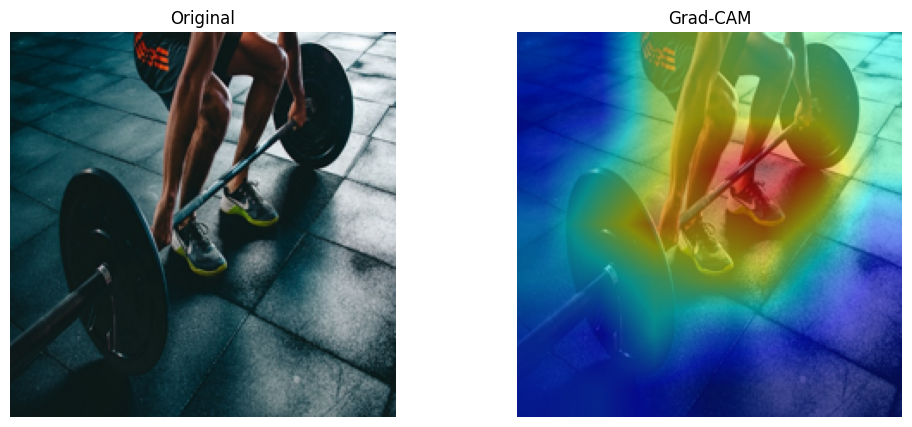

In [32]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = [list(image_embedder.backbone.children())[-2][-1]]

def get_gradcam(image):
    img_tensor = transform(image).unsqueeze(0).to(device)
    img_np     = np.array(image.resize((224, 224))) / 255.0

    # Temporarily enable gradients for frozen layers
    for param in image_embedder.parameters():
        param.requires_grad = True

    cam = GradCAM(model=image_embedder, target_layers=target_layer)
    grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0]

    # Freeze again after CAM computation
    for param in image_embedder.parameters():
        param.requires_grad = False

    visualization = show_cam_on_image(
        img_np.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )
    return visualization

# Test
url = "https://images.unsplash.com/photo-1517836357463-d25dfeac3438?w=640"
img = Image.open(BytesIO(requests.get(url).content)).convert('RGB')
heatmap = get_gradcam(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img.resize((224, 224)))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(heatmap)
axes[1].set_title('Grad-CAM')
axes[1].axis('off')
plt.show()